In [36]:
import pandas as pd
from networkx.utils.misc import graphs_equal
from scipy.spatial.distance import cosine
from collections import defaultdict
from scipy.stats import pearsonr
import numpy as np
import seaborn as sns
import networkx as nx
from cdlib.algorithms import leiden, louvain
import matplotlib.pyplot as plt

In [2]:
# Load nodes
nodes_df = pd.read_csv("hetionet-v1.0-nodes.tsv", sep="\t")
# Load edges
edges_df = pd.read_csv("hetionet-v1.0-edges.sif.gz", sep="\t", compression='gzip')

In [3]:
# retain only gene nodes
nodes_df_gene_only = nodes_df[nodes_df['kind'] == "Gene"]
# retain only gene-gene edges
# edges_df_gene_only = edges_df[(edges_df["source"].str.contains("Gene")) & (edges_df["target"].str.contains("Gene"))]
edges_df_gene_only = edges_df[edges_df["metaedge"] == 'GiG']

In [4]:
# combine all unique gene nodes from the edges_df
unique_genes = list(edges_df_gene_only.source.unique()) + list(edges_df_gene_only.target.unique())
unique_genes = list(set(unique_genes))
unique_genes.sort()

# assign unique node ids
gene_id_map = {node: idx + 1 for idx, node in enumerate(unique_genes)}

# add unique node ids to the nodes_df for ease of queries
nodes_df_gene_only['nx_gene_id'] = [gene_id_map[x] if x in gene_id_map else None for x in nodes_df_gene_only['id']]

mapped_edges_df_gene_only = pd.DataFrame({
	"src_id": edges_df_gene_only['source'].map(gene_id_map),
	"dst_id": edges_df_gene_only['target'].map(gene_id_map),
	"edge_id": range(1, len(edges_df_gene_only) + 1)
})

In [5]:
def generate_color_map(node_attributes):
    color_map = []
    n_colors = len(set(node_attributes.values()))
    palette = sns.color_palette("tab10", n_colors)
    palette = dict(zip(set(node_attributes.values()), palette))
    for value in node_attributes.values():
        color_map.append(palette[value])
    return color_map

In [6]:
HetionetG = nx.from_pandas_edgelist(mapped_edges_df_gene_only, 'src_id', 'dst_id')

In [7]:
import os
import pickle

np.random.seed(42)

node_position_filepath = './node_positions.pickle'
if os.path.exists(node_position_filepath):
    print("reading positions...")
    # load data
    with open(node_position_filepath, 'rb') as f:
        pos = pickle.load(f)

else:
    print("creating positions...")
    pos = nx.spring_layout(HetionetG, iterations=200)
    # save data
    with open(node_position_filepath, 'wb') as f:
        pickle.dump(pos, f)

reading positions...


In [38]:
node_clustered = louvain(HetionetG, resolution=1)
node_clustered = {k:v[0] for k,v in node_clustered.to_node_community_map().items()}
nx.set_node_attributes(HetionetG, node_clustered, "louvain")
color_map = generate_color_map(nx.get_node_attributes(HetionetG, 'louvain'))
nx.draw(HetionetG, pos, node_size = 20, node_color = color_map, with_labels = False)
plt.savefig("hetionet_clusters_gene-gene_interaction.png")
plt.close()

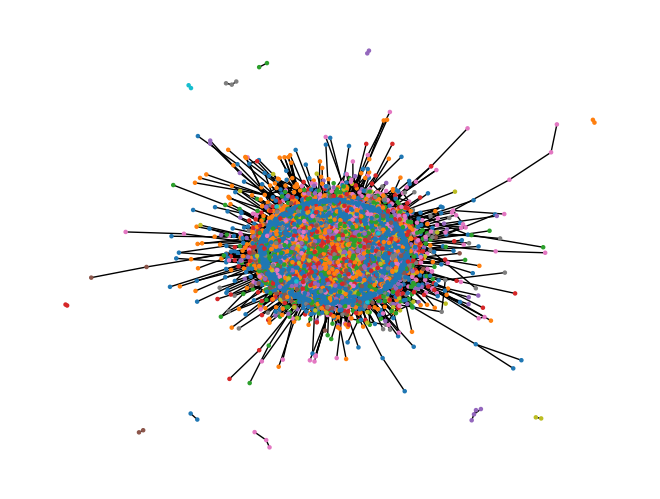

In [10]:
nx.draw(HetionetG, pos, node_size = 5, node_color = color_map, with_labels = False)

In [32]:
adsp_genes = pd.read_csv('score_upd_alzkb_mem.csv')

# retain only ADSP gene nodes
nodes_adsp_gene_only = nodes_df[(nodes_df['kind'] == "Gene") & (nodes_df['name'].isin(adsp_genes['Gene']) ) ]
# retain only edges connecting ADSP genes
edges_adsp_gene_only = edges_df[edges_df["source"].isin(nodes_adsp_gene_only['id']) & edges_df["target"].isin(nodes_adsp_gene_only['id'])]

# combine all unique gene nodes from the edges_df
unique_adsp_genes = list(edges_adsp_gene_only.source.unique()) + list(edges_adsp_gene_only.target.unique())
unique_adsp_genes = list(set(unique_adsp_genes))
unique_adsp_genes.sort()

# assign unique node ids
adsp_id_map = {node: idx + 1 for idx, node in enumerate(unique_adsp_genes)}

# add unique node ids to the nodes_df for ease of queries
nodes_adsp_gene_only['nx_gene_id'] = [adsp_id_map[x] if x in adsp_id_map else None for x in nodes_adsp_gene_only['id']]

mapped_edges_adsp_gene_only = pd.DataFrame({
	"src_id": edges_adsp_gene_only['source'].map(adsp_id_map),
	"dst_id": edges_adsp_gene_only['target'].map(adsp_id_map),
	"edge_id": range(1, len(edges_adsp_gene_only) + 1)
})

node_clustered = louvain(HetionetG, resolution=1)
node_clustered = {k:v[0] for k,v in node_clustered.to_node_community_map().items()}
nx.set_node_attributes(HetionetG, node_clustered, "louvain")
color_map = generate_color_map(nx.get_node_attributes(HetionetG, 'louvain'))
nx.draw(HetionetG, pos, node_size = 20, node_color = color_map, with_labels = False)


In [33]:
HetionetG = nx.from_pandas_edgelist(mapped_edges_adsp_gene_only, 'src_id', 'dst_id')
node_clustered = louvain(HetionetG, resolution=1)
node_clustered = {k:v[0] for k,v in node_clustered.to_node_community_map().items()}
nx.set_node_attributes(HetionetG, node_clustered, "louvain")
color_map = generate_color_map(nx.get_node_attributes(HetionetG, 'louvain'))
nx.draw(HetionetG, pos, node_size = 20, node_color = color_map, with_labels = False)

,src_id,dst_id,edge_id
559504,2883,2788,1
559509,600,2375,2
559514,566,2913,3
559515,1272,2762,4
559517,3099,39,5
...,...,...,...
1471630,763,1168,62250
1471633,2296,1799,62251
1471634,1520,296,62252
1471639,2262,2282,62253
